# Logistic Regression: Classification algorithm

In [18]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("datasnaek/chess")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'chess' dataset.
Path to dataset files: /kaggle/input/chess


In [19]:
!ls $path

games.csv


In [20]:
import pandas as pd

In [21]:
df = pd.read_csv(path+"/games.csv")

In [22]:
df.head(5)

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


In [23]:
df.columns

Index(['id', 'rated', 'created_at', 'last_move_at', 'turns', 'victory_status',
       'winner', 'increment_code', 'white_id', 'white_rating', 'black_id',
       'black_rating', 'moves', 'opening_eco', 'opening_name', 'opening_ply'],
      dtype='object')

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              20058 non-null  object 
 1   rated           20058 non-null  bool   
 2   created_at      20058 non-null  float64
 3   last_move_at    20058 non-null  float64
 4   turns           20058 non-null  int64  
 5   victory_status  20058 non-null  object 
 6   winner          20058 non-null  object 
 7   increment_code  20058 non-null  object 
 8   white_id        20058 non-null  object 
 9   white_rating    20058 non-null  int64  
 10  black_id        20058 non-null  object 
 11  black_rating    20058 non-null  int64  
 12  moves           20058 non-null  object 
 13  opening_eco     20058 non-null  object 
 14  opening_name    20058 non-null  object 
 15  opening_ply     20058 non-null  int64  
dtypes: bool(1), float64(2), int64(4), object(9)
memory usage: 2.3+ MB


In [25]:
X = df[["white_rating", 'black_rating']]
y = df['winner']

In [26]:
X.shape, y.shape

((20058, 2), (20058,))

In [27]:
X.head(5)

,white_rating,black_rating
0,1500,1191
1,1322,1261
2,1496,1500
3,1439,1454
4,1523,1469


In [28]:
y.head()

,winner
0,white
1,black
2,white
3,white
4,white


In [29]:
y.unique()

array(['white', 'black', 'draw'], dtype=object)

In [30]:
df = df[df['winner'].isin(['white', 'black'])].copy()

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19108 entries, 0 to 20057
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              19108 non-null  object 
 1   rated           19108 non-null  bool   
 2   created_at      19108 non-null  float64
 3   last_move_at    19108 non-null  float64
 4   turns           19108 non-null  int64  
 5   victory_status  19108 non-null  object 
 6   winner          19108 non-null  object 
 7   increment_code  19108 non-null  object 
 8   white_id        19108 non-null  object 
 9   white_rating    19108 non-null  int64  
 10  black_id        19108 non-null  object 
 11  black_rating    19108 non-null  int64  
 12  moves           19108 non-null  object 
 13  opening_eco     19108 non-null  object 
 14  opening_name    19108 non-null  object 
 15  opening_ply     19108 non-null  int64  
dtypes: bool(1), float64(2), int64(4), object(9)
memory usage: 2.4+ MB


In [32]:
df.head()

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


In [33]:
X = (df['white_rating']-df['black_rating']).to_frame()
y = df['winner']

In [34]:
X.head(5)

,0
0,309
1,61
2,-4
3,-15
4,54


In [35]:
y = y.map({'white': 0, 'black': 1})

In [36]:
X.shape, y.shape

((19108, 1), (19108,))

In [37]:
y

,winner
0,0
1,1
2,0
3,0
4,0
...,...
20053,0
20054,1
20055,0
20056,0


In [38]:
y.unique()

array([0, 1])

In [39]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [40]:
X_train.shape, X_test.shape

((13375, 1), (5733, 1))

In [41]:
from sklearn.linear_model import LogisticRegression

In [42]:
model = LogisticRegression()

In [43]:
model.fit(X_train, y_train)

LogisticRegression()

In [44]:
model.coef_, model.intercept_

(array([[-0.0038084]]), array([-0.06247538]))

In [45]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [46]:
y_pred = model.predict(X_test)

In [47]:
accuracy = accuracy_score(y_test, y_pred)

In [48]:
f"{accuracy*100:.2f}%"

'65.18%'

In [49]:
cm = confusion_matrix(y_test, y_pred)

In [50]:
cm

array([[2149,  898],
       [1098, 1588]])

In [51]:
TN = cm[0, 0]
TP = cm[1, 1]
FN = cm[1, 0]
FP = cm[0, 1]


In [52]:
TP, TN, FP, FN

(np.int64(1588), np.int64(2149), np.int64(898), np.int64(1098))

In [53]:
# precision
precision = TP/(TP+FP)
precision

np.float64(0.6387771520514883)

In [54]:
# recall
recall = TP/(TP+FN)
recall

np.float64(0.5912137006701415)

In [55]:
# Specifity
spec = TN/(TN+FP)
spec

np.float64(0.7052838857893009)

In [56]:
# F1-Score
F1_score = (2 * precision * recall)/(precision+recall)
F1_score

np.float64(0.6140757927300852)

In [57]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [58]:
model = LogisticRegression()

In [59]:
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [60]:
model.coef_, model.intercept_

(array([[-0.94661308]]), array([-0.09310567]))

In [61]:
y_pred = model.predict(X_test_scaled)

In [62]:
accuracy = accuracy_score(y_test, y_pred)

In [63]:
f"{accuracy*100:.2f}%"

'65.18%'

# Scratch

In [85]:
X = df[['white_rating', 'black_rating']]
y = df['winner'].map({'white': 0, 'black': 1})

In [86]:
X.shape, y.shape

((19108, 2), (19108,))

In [87]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [88]:
X.shape, y.shape

((19108, 2), (19108,))

In [89]:
import numpy as np
from matplotlib import pyplot as plt

In [90]:
X_train

,white_rating,black_rating
8146,1370,1327
2058,1437,1475
9478,1525,1888
5814,1749,2040
1836,1343,1328
...,...,...
11803,1500,1233
12543,1085,2171
5653,1673,1717
905,1544,1523


In [91]:
X_tr = X_train["white_rating"]-X_train['black_rating']
print(X_tr.shape)
X_mean = np.mean(X_tr)
X_std = np.std(X_tr)
X_tr = (X_tr-X_mean)/X_std
y_train = np.array(y_train).flatten()

(13375,)


In [92]:
w = 0
b = 0
learning_rate = 0.01
z = w*X_tr+b
sigmoid  = 1/(1+np.exp(-z))
y_pred = sigmoid
epoch = 1000

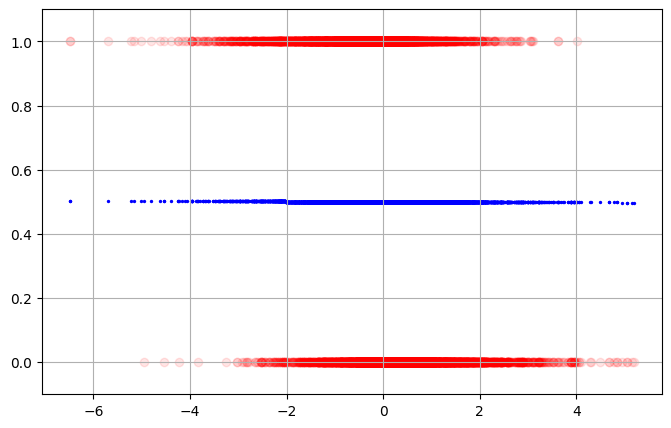

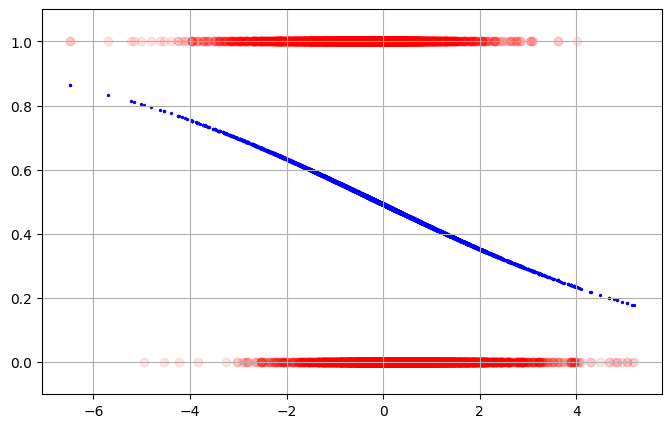

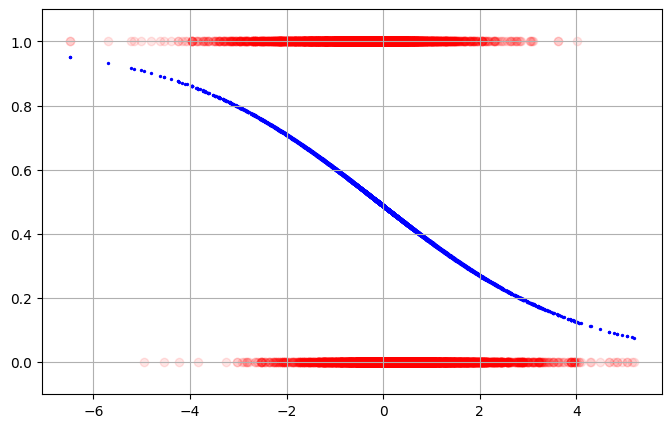

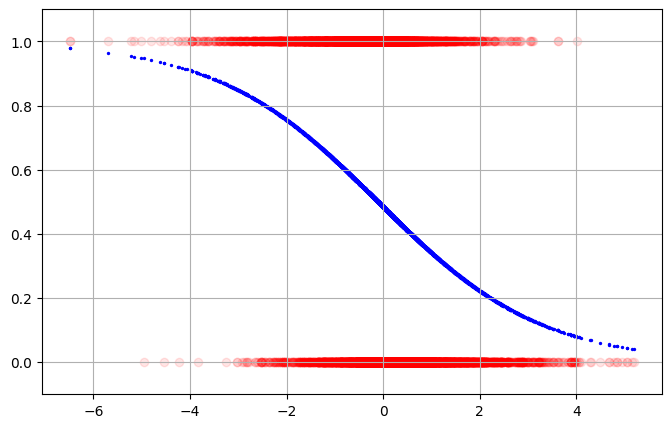

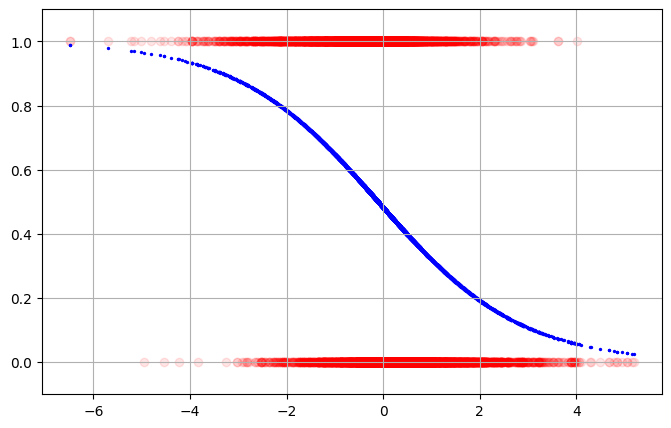

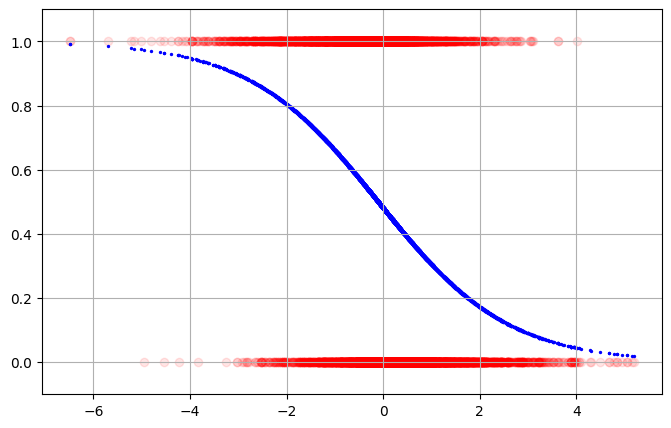

In [93]:
for i in range(epoch+1):
  db = np.mean(y_pred-y_train)
  dw = np.mean((y_pred-y_train)*X_tr)
  w = w-learning_rate*dw
  b = b-learning_rate*db
  z = w*X_tr+b
  sigmoid  = 1/(1+np.exp(-z))
  y_pred = sigmoid
  if i%200==0:
    plt.figure(figsize=(8, 5))
    plt.scatter(X_tr, y_train, color='red', alpha=0.1)
    plt.scatter(X_tr, y_pred, color='blue', s=2)
    plt.ylim(-0.1, 1.1)
    plt.grid(True)
    plt.show()


In [94]:
# Accuracy
threshold = 0.5

results = (y_pred>threshold).astype(int)

correct = np.sum(results == y_train)
all_games = len(y_train)

accuracy = correct/all_games
accuracy

np.float64(0.6498691588785047)

In [95]:
w, b

(np.float64(-0.7454538973113564), np.float64(-0.07815286024925219))

In [96]:
### Test Accuracy
X_te = X_test['white_rating']-X_test['black_rating']
X_te = (X_te - X_mean)/X_std
z_test = w * X_te + b
y_test_pred = 1/(1+np.exp(-z_test))
results_test = (y_test_pred >= threshold).astype(int)
y_test_flat =np.array(y_test).flatten()
correct_test = np.sum(results_test == y_test_flat)
tests_length = len(y_test_flat)
accuracy = correct_test/tests_length
f"{accuracy*100:.2f}%"


'65.27%'